## MVP - Machine Learning & Analytics

Nome: Alexandre Domingues Caspechaque  
Matrícula: XXXXXXXXXXXXXXX  
Data: 16/06/2026  
Dataset: MIT-BIH Arrhythmia Database (ECG Heartbeat Categorization)
Tipo de problema: Classificação supervisionada multiclasse
<hr>

### **2. Definição do Problema**

O eletrocardiograma (ECG) é um exame recorrente na avaliação das atividades elétricas do coração. Analisando o traçado e ritmo de cada batimento conseguimos identificar irregularidades como arritmias. A análise manual desses sinais, é demorada e sujeita a erro humano como qualquer outra atividade, especialmente por se tratar de registros longos com monitoramento contínuo. Dessa forma, o MVP em questão tem como objetivo realizar a **classificação automática dos batimentos cardíacos a partir do sinal ECG**, atribuindo cada batimento cardíaco a uma dentre as cinco categorias clínicas definidas pela AAMI (Associação de Avanço de Instrumentação Médica). Por se tratar de um problema com mais de uma classe, o chamamos de classificação supervisionada multiclasse.  
  
Sabendo disso, o modelo proposto tem como intuito receber o sinal de um batimento cardíaco, e prever a qual das cinco classes ele pertence. Entende-se que o modelo não será 100% efetivo e não alcança totalmente as expectativas, porém, o fato de apenas identificar um padrão anormal para as batidas já são de grande valia no aspecto médico. As classes anteriormente citadas são representadas pela última coluna do dataset (índice 187), e pode assumir cinco valores. Classificamos este problema dentro do campo de Machine Learning pois ele apresenta um padrão a ser aprendido, possui dados rotulados em quantidade suficiente e é uma tarefa repetitível e escalável.

| Código | Classe (AAMI) | Descrição |
|:------:|:--------------|:----------|
| 0 | N | Batimento normal |
| 1 | S | Batimento supraventricular ectópico |
| 2 | V | Batimento ventricular ectópico |
| 3 | F | Batimento de fusão |
| 4 | Q | Batimento desconhecido / com marca-passo |  

A escolha por essa base de dados se dá pela riqueza em análise técnica que ele permite, além da interface com engenharia biomédica, na área de processamento de sinais, onde já tive experiência durante a graduação em Engenharia Elétrica, participando no reconhecimento de sinais eletromiográficos para acionamento de próteses humanas.
  
<hr>

### **3. Apresentação do DataSet**

#### **3.1. Introdução**
[X] Fonte dos Dados.  
[X] Quantidade de registros.  
[X] Quantidade de atributos.  
[X] Descrição de principais variáveis.  
[X] Identificação da variável-alvo, quando houver.  
[X] Possíveis limitações do dataset.  
[X] Critérios utilizados para escolher a base.  
[X] Visualização das primeiras linhas.
[X] Tipos de variáveis.  
[X] Estatísticas descritivas.  
[X] Verificação de valores ausentes.  
[ ] Distribuição de variável-alvo.  
[ ] Análise de desbalanceamento, quando for classificação.  
[X] Gráficos ou tabelas que ajudem a entender o problema.  

O dataset utilizado é o MIT-BIH Arrhythmia Database, na versão pré-processada para Machine Learning conhecida como ECG Heartbeat Categorization Dataset, preparada por Kachuee, Fazeli e Sarrafzadeh (2018). A base foi desenvolvida pelo MIT e pelo Beth Israel Hospital e é considerada uma referência para avaliação de algoritmos de classificação de arritmias.

| Conjunto | Registros (Batimentos) | Atributos | Variável-alvo |
|:------:|:--------------|:----------|:----------|
| Treino | 87.554 | 187 | 1 | 
| Teste | 21.892 | 187 | 1 |
| Total | 109.446 | 187 | 1 |

As colunas 0 a 186 representam o sinal de ECG de um batimento, amostrado ao longo do tempo. Cada coluna é a amplitude do sinal em um instante, já normalizada dentro do intervalo de [0,1]. Batimentos mais curtos do que a janela padrão são preenchidos com zeros ao final, garantindo que todas as amostras tenham o mesmo comprimento. A coluna 187 é o rótulo da classe de batimento.

Apesar disso, o dataset apresenta algumas limitações e restrições identificadas, listadas a seguir como:
- O dataset possui um desbalanceamento, pois 83% das medidas registradas são referentes a batimentos normais.
- O dataset registra batimentos independentes, ou seja, o ritmo entre batimentos não é identificado por ele.
- O dataset é um modelo de ferramenta acadêmica, sem propósito claro de diagnóstico médico.


In [17]:
# Para visualização dos dados, precisamos primeiramente realizar a importação de módulos importantes no tratamento de informações.
# A biblioteca PANDAS nos permite neste contexto realizar a leitura de arquivos .csv
from pandas import read_csv, DataFrame


#Leitura do repositório salvo no Github. Para este projeto, o próprio dataset já nos entrega bases separadas em treino e teste.
dataset = "https://raw.githubusercontent.com/alexandredc2/Heartbeat_Categorization/main/"
base_treino = read_csv(dataset + "mitbih_train.csv.gz", header=None, compression="gzip")
base_teste  = read_csv(dataset + "mitbih_test.csv.gz", header=None, compression="gzip")


# Visualização da quantidade de linhas e quantidade de colunas disponíveis dentro da base treino e da base teste.
print("#---------------------------------- VISUALIZAÇÃO QUANTIDADE DE LINHAS DATASET---------------------------------#")
print(f"Base de Treino ---> {base_treino.shape[0]} batimentos x {base_treino.shape[1]} colunas")
print(f"Base de Teste ----> {base_teste.shape[0]} batimentos x {base_teste.shape[1]} colunas")
print("#-------------------------------------------------------------------------------------------------------------#\n")


# Visualização das primeiras 5 linhas da tabela
# Como existem 188 colunas ao todo, foi selecionado para pré-visualização as primeiras 5 colunas e a coluna da variável target
print("#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TREINO --------------------------------------#")
print(base_treino.iloc[:, list(range(5)) + [187]].head())
print(base_treino.dtypes.value_counts())
print("#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TESTE ---------------------------------------#")
print(base_teste.iloc[:, list(range(5)) + [187]].head())
print(base_teste.dtypes.value_counts())
print("#-------------------------------------------------------------------------------------------------------------#\n")

#---------------------------------- VISUALIZAÇÃO QUANTIDADE DE LINHAS DATASET---------------------------------#
Base de Treino ---> 87554 batimentos x 188 colunas
Base de Teste ----> 21892 batimentos x 188 colunas
#-------------------------------------------------------------------------------------------------------------#

#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TREINO --------------------------------------#
        0         1         2         3         4    187
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.0
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.0
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.0
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.0
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.0
float64    188
Name: count, dtype: int64
#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TESTE ---------------------------------------#
        0         1         2         3         4    187
0  1.0000

O trecho anterior de código anterior nos mostra uma pré-visualização das bases de treino e de teste, indicando que as colunas de atributos são essencialmente do tipo numérico, assim como a coluna da variável target (188 colunas do tipo float64).

In [ ]:
print("#----------------------- ESTATÍSTICAS DAS 5 PRIMEIRAS COLUNAS -----------------------#")
print(base_treino.iloc[:, :5].describe())
print("#------------------------------------------------------------------------------------#\n")

Analisando as 5 primeiras colunas pelo método **.describe()** do objeto DataFrame e Series do Pandas, conseguimos varrer as colunas selecionadas e calcular estatísticas de análise interessantes (contagem, média, mediana, máximo, mínimo, entre outros). Com ele vemos por exemplo que não há existência de valores ausentes nessas colunas (todas têm o número completo de batimentos), assim como o **min** e o **max** (respectivamente marcando 0 e 1) indicando que os valores estão normalizados dentro desta faixa.  

No entanto, estamos analisando e resumindo 187 colunas de atributos em apenas 5 (ele não seria capaz de exibir a estatística de todas as colunas selecionadas) e isso não torna nosso parâmetro de análise confiável. Sendo assim, o trecho de código abaixo nos mostra a representação gráfica do sinal, ajudando a ter uma identificação visual e completa dos dados.

In [ ]:
# Para visualizar graficamente os dados precisamos utilizar a biblioteca de geração gráfica matplotlib
import matplotlib.pyplot as plt


# Criamos um dicionário para tornar a visualização de cada classe mais intuitiva na leitura:
identifica_classes = {
    0: "N - Normal",
    1: "S - Supraventricular",
    2: "V - Ventricular",
    3: "F - Fusão",
    4: "Q - Desconhecido/Marca-passo"
}


# A função abaixo irá criar uma figura principal com 5 subgráficos (um para cada classe):
fig, axes = plt.subplots(1, 5, figsize=(20,4))

for classe, ax in zip(range(5), axes):
    exemplo = base_treino[base_treino[187] == classe].iloc[0, :187]
    ax.plot(exemplo.values)
    ax.set_title(identifica_classes[classe])
    ax.set_xlabel("Tempo (amostras)")
    ax.set_ylabel("Amplitude normalizada")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Agora com o gráfico conseguimos visualizar e confirmar o que o método **.describe()** nos havia indicado anteriormente. Com as visualizações conseguimos ver ainda que a partir de um determinado tempo (por exemplo, após t=100 no gráfico de classe Normal) há a ocorrência do **zero padding**, mas por que isso acontece? Bom, na prática os batimentos reais não vão ter todos a mesma duração (um coração batendo mais rápido terá os batimentos mais curtos, enquanto que o coração batendo mais devagar terá os batimentos mais longos), no entanto para tratamento de dados em Machine Learning uma premissa é que as colunas possuam todas a mesma quantidade de informações. Por este motivo, os autores do dataset optaram pelo padding de preenchimento dos espaços faltantes com o valor 0 até completar 187.

No início deste documento foi citado que uma das limitações deste dataset é o alto desbalanceamento entre as classes existentes, o que pode afetar as métricas utilizadas para avaliação e treinamento dos modelos. Podemos ver visualmente o desbalanceamento citado por meio de um pequeno trecho de código, conforme abaixo:

#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TREINO) --------------------#
                      Classe  Quantidade  Percentual (%)
                  N - Normal       72471           82.77
        S - Supraventricular        2223            2.54
             V - Ventricular        5788            6.61
                   F - Fusão         641            0.73
Q - Desconhecido/Marca-passo        6431            7.35
#----------------------------------------------------------------------------------#

#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TESTE) --------------------#
                      Classe  Quantidade  Percentual (%)
                  N - Normal       18118           82.76
        S - Supraventricular         556            2.54
             V - Ventricular        1448            6.61
                   F - Fusão         162            0.74
Q - Desconhecido/Marca-passo        1608            7.35
#----------------------------------------------------------

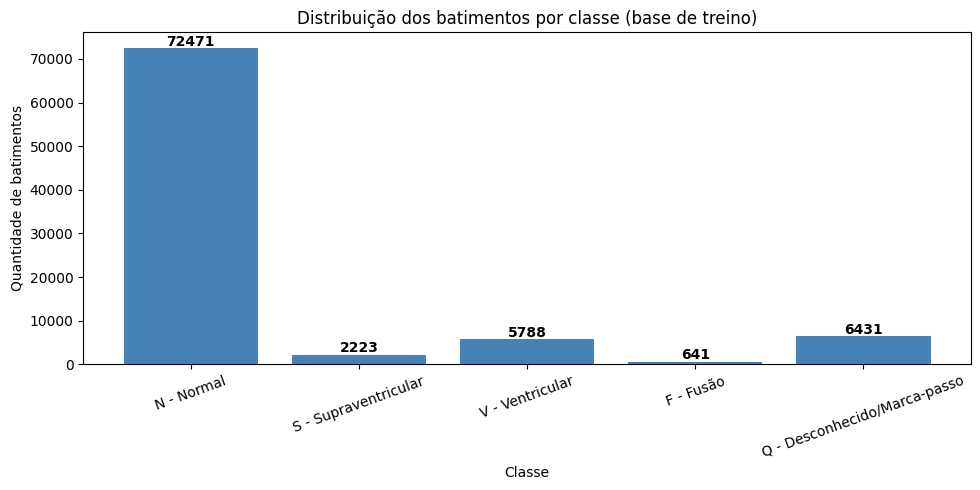

In [ ]:
contagem_treino = base_treino[187].value_counts().sort_index()
contagem_teste  = base_teste[187].value_counts().sort_index()
percentual_treino = base_treino[187].value_counts(normalize=True).sort_index() * 100
percentual_teste =  base_teste[187].value_counts(normalize=True).sort_index() * 100

resumo_treino = DataFrame({
    "Classe" : [identifica_classes[c] for c in contagem_treino.index],
    "Quantidade" : contagem_treino.values,
    "Percentual (%)" : percentual_treino.values.round(2)
})
resumo_teste = DataFrame({
    "Classe" : [identifica_classes[c] for c in contagem_teste.index],
    "Quantidade" : contagem_teste.values,
    "Percentual (%)" : percentual_teste.values.round(2)
})

print("#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TREINO) --------------------#")
print(resumo_treino.to_string(index=False))
print("#----------------------------------------------------------------------------------#\n")

print("#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TESTE) --------------------#")
print(resumo_teste.to_string(index=False))
print("#----------------------------------------------------------------------------------#\n")

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([identifica_classes[c] for c in contagem_treino.index], contagem_treino.values, color="steelblue")
ax.set_title("Distribuição dos batimentos por classe (base de treino)")
ax.set_ylabel("Quantidade de batimentos")
ax.tick_params(axis='x', rotation=20)

# Adiciona o número em cima da barra
for i, v in enumerate(contagem_treino.values):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
